# Spoken Language Processing - Instituto Superior Técnico
### Laboratory Assignment 2 - Native Language Identification challenge

The second laboratory assignment of the course is designed to simulate a **native language identification** challenge. In this challenge, partipants (a.k.a students enrolled in the course) receive a train, development and evaluation (blind) data set, and a set of (weak) baseline systems for the task at hand: closed-set identification of the native language of foreign English (L2) speakers in a given audio file out of a set of four target native L1 languages: Arabic,  Korean,  Spanish and Turkish.

The **goal** for each participant is to develop/build the best native language identification system. To this end, participants are first required to complete the lab Notebooks and then encouraged to incorporate other techniques and explore any approach that permit improving their results.

During the first week, students are expected to:
- Understand the main components of two simple baseline systems: one based on **MFCC** features and **GMM** models and another based on **openSMILE** features and **SVM** models.
- Complete and run the main components of these baselines presented in the [`lab2_classical.ipynb`](https://gitlab.rnl.tecnico.ulisboa.pt/ist-slp/slp25/speech-processing-lab-2/) notebook.
- Propose, develop and explore simple modifications to the feature extraction configurations.
- Propose, develop and explore simple modifications to the GMM and SVM model configurations.
- Evaluate the models on the development partition.

During the second week, students are expected to:
- Understand the main components of two modern sytems: one based on speaker embeddings and the other on self-supervised learning features and models.
- Complete and run the main components of these systems presented in the  [`lab2_xvec.ipynb`](https://gitlab.rnl.tecnico.ulisboa.pt/ist-slp/slp25/speech-processing-lab-2/) and [`lab2_ssl.ipynb`](https://gitlab.rnl.tecnico.ulisboa.pt/ist-slp/slp25/speech-processing-lab-2/)  notebooks.
- Propose, develop and explore simple modifications, including testing different feature extractors version and downstream classifiers.
- Evaluate the models on the development partition.
- Propose, develop, extend, combine and/or modify the different systems to obtain the best possible native language identifier.
- Obtain predictions for the blind test partition and prepare the submission.



## About the data

The data consists of mono audio files sampled at 16 kHz all of them containing English speech (L2) spoken by native speakers of one of the following L1 target languages: Arabic (`'ARA'`), Korean (`'KOR'`), Spanish (`'SPA'`) and Turkish (`'TUR'`).
```python 
LANGUAGES = ('ARA',  'KOR',  'SPA',  'TUR')
```

The dataset is organized in 4 partitions:
- `'train'`: This is the full training set, consisting of 1200 audio samples of approximately 45-seconds each containg speech from English students with  different L1 backgrounds. (**ATENTION**: Do not use this dataset for training your models, unless your system is very fast or if you want to build your final model. It can be slow).
- `'train100'`: This is a subset of the full training set that consists of 100 audio files per target L1 language (**RECOMMENDATION**: Use this partition in your quick experiments, to more rapidly validate alternatives)
- `'dev'`: This is the development set. It contains the same kind of segments as the training partitions. You will typically use this to validate the quality of your model.
- `'evl'`: This is the evaluation set. It contains the same kind of segments as the training partitions. You don't have the groud-truth for this set. You are expected to generate a prediction file and submit it.

The data used in this challenge is a subset of the [ETS Corpus of Non-Native Spoken English](http://dx.doi.org/10.21437/Interspeech.2016-129).

The difference is that only four L1 target languages are considered instead of eleven, and that the original development partition has been split in the development and evaluation sets used in this course.

## Before starting

We suggest to use [Visual Studio Code](https://code.visualstudio.com) with all the necessary extensions to run Jupyter notebooks. Alternatively, [Google Colab](https://colab.research.google.com) can also be used, but one needs to be carefull with potential data persistance issues.

In the case of running these notebooks in a local machine, we strongly recommend to create a new [virtual enviroment](https://code.visualstudio.com/docs/python/environments#_creating-environments) for this project. Python interpreter version should not be lower than **Python 3.9**.

The following conditions are necessary to run correctly this notebook:

*   All modules included in the `requirements.txt` file need to be 
installed in the Python environment. In a local installation, you can run in the command line: `pip install -r requirements.txt`
*   The module `pf_tools` needs to be accessible (if you are using Google Colab, you will need to copy the `pf_tools.py` every time you start a new session).

In [16]:
from pf_tools import CheckThisCell

## How can you download (and process) the data

### Set-up the working and data directories
The first thing we have to do is to set our working directory. If you are using Google Colab, you probably want to mount Google Drive to keep persistent information, such as data, features and models. If you are not using Google Colab, you rather comment or delete the following code cell:

In [17]:
import os 

CWD = os.getcwd() # <--- Change this variable to your working directory. The default is the current directory
DATADIR = f'{CWD}/ets_data/' # <--- Change this variable to your folder containig the ETS data
if not os.path.isdir(DATADIR):
    os.mkdir(DATADIR)

os.chdir(CWD)
print(f'Current working directory is set to {CWD}')   
print(f'Your ETS data folder is {DATADIR}')

Current working directory is set to /Users/leonard/Dropbox/Le_Papa/Universitaet/KIT Master/Erasmus/Vorlesungen/Spoken Language Processing/Lab 2/SLP_Lab2
Your ETS data folder is /Users/leonard/Dropbox/Le_Papa/Universitaet/KIT Master/Erasmus/Vorlesungen/Spoken Language Processing/Lab 2/SLP_Lab2/ets_data/


### Use the `ETS` class to download and process challenge data

#### Data download 

The class `ETS` permits downloading, transforming and storing the different data partitions. Each `ETS` instance can be used to iterate over all the samples of the partition. It can also be used in combination with pytorch dataloader to read batches of data to train neural networks with pytorch. For instance, consider the following piece of code:


In [18]:
import numpy as np
from pf_tools import ETS
import librosa 

def extract_raw_data(filename):
    y, _ = librosa.load(filename, sr=16000, mono=True)
    return y.reshape(-1,1)
    
train_ets = ETS(DATADIR, 'train100', transform_id='raw', audio_transform=extract_raw_data)


This code spinet first downloads and uncompresses the .tgz file containing all the necessary data of the selected   partition (`'train100'`). The audio files are stored to disk (in DATADIR/train100/audio/) and also a key file (DATADIR/train100/key.lst). Have a look to the folder just created and its contents.

(Notice that the downloading of a specific dataset partition only happens the first time the ETS class is instantiated)

In [19]:
!ls ets_data/train100

audio   key.lst raw     raw10


You can plot the waveform and spectrogram of one of the audio files downloaded:

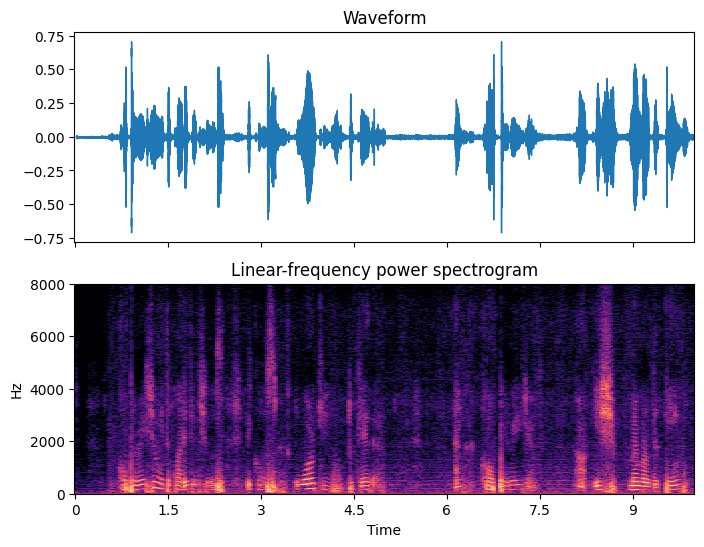

In [20]:
from pf_tools import audioplot

%matplotlib inline
audioplot(f'{DATADIR}/train100/audio/train_0003.wav', sr=16000, mono=True, duration=10)


And listen to some examples: 

In [21]:
import IPython.display as ipd
ipd.Audio(f'{DATADIR}/train100/audio/train_0003.wav') # load a local WAV file

#### Audio file transformation

In addition to the parameter for selecting the dataset partition, the `ETS` class has a mandatory argument named `audio_transform` that corresponds to a callable (function) of a single  argument.  

**Audio transformations** receive a filename of an audio file, load the contents, apply some sort of transformation or **feature extraction**, and return an array of dimensions (NxD), in which N is the time dimension and D the dimension of the feature vector.  The resulting features are stored in disk in the folder indicated with the argument `transform_id`. 

In this particular case, the  audio transformation `'extract_raw_data'` simply loads the audio file and returns the raw audio data in an array of D=1. The result is stored to disk DATADIR/train100/raw/. You can have a look to the contents of the folder.

(If the feature extraction process is interrupted, you will need to delete the corresponding tranformation folder to restart)

In [22]:
!ls ets_data/train100/raw/

train_0003 train_0143 train_0292 train_0439 train_0569 train_0723 train_0880
train_0004 train_0145 train_0293 train_0440 train_0571 train_0725 train_0881
train_0007 train_0152 train_0294 train_0442 train_0573 train_0727 train_0883
train_0008 train_0157 train_0295 train_0444 train_0574 train_0728 train_0884
train_0011 train_0160 train_0296 train_0446 train_0582 train_0729 train_0885
train_0016 train_0165 train_0297 train_0447 train_0583 train_0731 train_0886
train_0017 train_0167 train_0303 train_0448 train_0585 train_0739 train_0887
train_0019 train_0168 train_0309 train_0449 train_0588 train_0743 train_0888
train_0020 train_0172 train_0310 train_0454 train_0589 train_0745 train_0892
train_0021 train_0175 train_0313 train_0457 train_0590 train_0748 train_0895
train_0022 train_0176 train_0314 train_0459 train_0592 train_0750 train_0897
train_0031 train_0178 train_0318 train_0466 train_0593 train_0751 train_0902
train_0033 train_0180 train_0320 train_0467 train_0601 train_0755 train_0904

**NOTE**  The `ETS` class has some additional parameters that permit uniformily segmenting the output of the audio transformation (with configurable size and stride), applying additional transformations to each segment and storing the result as individual feature files, that will be recovered when iterating over the `ETS` instance. Overall, the combination of audio and segment transformations permits quite flexible feature extraction pipeline that (hopefully) can match the needs of almost any training setting. In the remaing, for sake of simplicity, we will consider that for each audio file a single feature array/file is generated.

### Iterating data

As mentioned previously, once we have instanciated an ETS dataset, it can be iterated to have access to each data sample (including feature data, label and identifier).

For instance, we can retrieve the first feature array as follows:

In [23]:
sample, label, basename = next(iter(train_ets)) 

print(f'Sample shape: {sample.shape}')
print(f'Label class: {label}')
print(f'Identifier file: {basename}')

Sample shape: (748800, 1)
Label class: SPA
Identifier file: train_0003


Or we can iterate the complete dataset:

In [24]:
import time
start = time.time()
for i, sample in enumerate(train_ets):
    data, label, basename = sample # array, str, str
    if i % 25 == 0:
        print(i, data.shape, label, basename)

print(f'Finished reading all data in {time.time() - start}')

0 (748800, 1) SPA train_0003
25 (742400, 1) SPA train_0064
50 (742400, 1) ARA train_0130
75 (748800, 1) TUR train_0193
100 (748800, 1) SPA train_0259
125 (748800, 1) TUR train_0313
150 (742400, 1) KOR train_0392
175 (742400, 1) KOR train_0440
200 (742400, 1) TUR train_0498
225 (742400, 1) SPA train_0550
250 (723200, 1) KOR train_0622
275 (742400, 1) KOR train_0693
300 (748800, 1) TUR train_0750
325 (748800, 1) SPA train_0811
350 (748800, 1) SPA train_0883
375 (742400, 1) KOR train_0993
Finished reading all data in 0.5008652210235596


Now you can use the `ETS` class to check the  number of files and size (in minutes) of the training set for each target language. You should keep these numbers to include in your system description paper:

In [25]:
LANGUAGES = ('ARA',  'KOR',  'SPA', 'TUR')    
train_ets = ETS(DATADIR, 'train100', transform_id='raw', audio_transform=extract_raw_data)
# train_ets = ETS(DATADIR, 'train', transform_id='raw', audio_transform=extract_raw_data)

num_files = dict().fromkeys(LANGUAGES, 0)
num_samples = dict().fromkeys(LANGUAGES, 0)

for sample in train_ets:
    data, label, basename = sample
    num_files[label] += 1
    num_samples[label] += data.shape[0]

sampling_rate = 16000
for lang in LANGUAGES:
    print(f'{lang}:\t{num_files[lang]}\t{num_samples[lang]/(60*sampling_rate)} minutes')

# The expected output should be something like for the train100:
# ARA:	100	77.58 minutes
# KOR:	100	77.37333333333333 minutes
# SPA:	100	77.84666666666666 minutes
# TUR:	100	77.50666666666666 minutes
#
# And the following gor train:
# ARA:	300	232.82666666666665 minutes
# KOR:	300	232.06666666666666 minutes
# SPA:	300	234.42666666666668 minutes
# TUR:	300	232.50666666666666 minutes

ARA:	100	77.58 minutes
KOR:	100	77.37333333333333 minutes
SPA:	100	77.84666666666666 minutes
TUR:	100	77.50666666666666 minutes


### Processing data in batches

Most common neural network learning recipes process data in batches of several data samples. 
For this purpose, the `ETS` class extends the `torch.utils.data.Dataset` and it can be used in combination with a Pytorch DataLoader to read data in batches. 

To build batches, the dimension of the samples of one batch need to be same. 
For exemplification purposes, we will change the `'extract_raw_data'` function to receive an additional parameter with duration to be extracted:  

In [26]:
def extract_raw_data(filename, duration=None):
    y, _ = librosa.load(filename, sr=16000, mono=True, duration=duration)
    return y.reshape(-1,1)

Now, we instantiate the `ETS` setting the duration of the raw data samples to 10 seconds. 

In [27]:
train_ets_10= ETS(DATADIR, 'train100', 
                     transform_id='raw10', 
                     audio_transform=lambda x: extract_raw_data(x, duration=10))

And we create the data loader and iterate to obtain batches of training samples:

In [28]:
import torch 

# Create data loader
train_batches = torch.utils.data.DataLoader(
        dataset=train_ets_10,
        batch_size=8,
        shuffle=True
)

# Read data in batches
start = time.time()
for i, batch in enumerate(train_batches):
    data, label, basename = batch
    print('batch', i, data.shape, len(label), len(basename))

print(f'Finished reading all data in {time.time() - start}')

batch 0 torch.Size([8, 160000, 1]) 8 8
batch 1 torch.Size([8, 160000, 1]) 8 8
batch 2 torch.Size([8, 160000, 1]) 8 8
batch 3 torch.Size([8, 160000, 1]) 8 8
batch 4 torch.Size([8, 160000, 1]) 8 8
batch 5 torch.Size([8, 160000, 1]) 8 8
batch 6 torch.Size([8, 160000, 1]) 8 8
batch 7 torch.Size([8, 160000, 1]) 8 8
batch 8 torch.Size([8, 160000, 1]) 8 8
batch 9 torch.Size([8, 160000, 1]) 8 8
batch 10 torch.Size([8, 160000, 1]) 8 8
batch 11 torch.Size([8, 160000, 1]) 8 8
batch 12 torch.Size([8, 160000, 1]) 8 8
batch 13 torch.Size([8, 160000, 1]) 8 8
batch 14 torch.Size([8, 160000, 1]) 8 8
batch 15 torch.Size([8, 160000, 1]) 8 8
batch 16 torch.Size([8, 160000, 1]) 8 8
batch 17 torch.Size([8, 160000, 1]) 8 8
batch 18 torch.Size([8, 160000, 1]) 8 8
batch 19 torch.Size([8, 160000, 1]) 8 8
batch 20 torch.Size([8, 160000, 1]) 8 8
batch 21 torch.Size([8, 160000, 1]) 8 8
batch 22 torch.Size([8, 160000, 1]) 8 8
batch 23 torch.Size([8, 160000, 1]) 8 8
batch 24 torch.Size([8, 160000, 1]) 8 8
batch 25 t

### Cleaning up

Before starting Part 1 of this lab assignment:
* You should delete the folders containing the dummy features that you just generated (_'raw'_, _'raw10'_) from the two train data partitions.
* You can also delete the _.tgz_ files if you need to save space.

# What should you deliver at the end of this lab assignment?
You should deliver the following three elements:
- You must submit (via [Kaggle](https://www.kaggle.com/t/8d80747e0c474688a83024aabdfe1ab0) and Fênix) at least one prediction file in the format that will be described in the Notebook of part1.
- You must submit (via Fênix) all the modified notebooks (part0, part1 and part2) and any additional code used for your proposed system(s).
- You must submit a report (via Fênix) of maximum 2 pages describing your work, your system(s), approaches explored (may be unsuccesful), parameters explored, lessons learnt, results on the dev partition, etc. You can use the following Overleaf template for the report: [report](https://www.overleaf.com/latex/templates/interspeech-2023-paper-kit/kzcdqdmkqvbr)


# Contacts and support
You can contact the professors during the classes or the office hours.

Particularly, for this second laboratory assignment, you should contact Prof. Alberto Abad: alberto.abad@tecnico.ulisboa.pt



